In [1]:
!pip install transformers datasets nltk spacy

In [2]:
import pandas as pd
import numpy as np
import torch
import re
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
from torch.optim import AdamW
from datasets import Dataset
import nltk
from sklearn.metrics import *

In [3]:
#Sampled Demonstration Of our skills in
imdb_data = load_dataset("imdb")

train = pd.DataFrame(imdb_data['train'])
test = pd.DataFrame(imdb_data['test'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [4]:
#a regex function to clean the dataset
def clean_text(text):
    text = text.lower()

    #Removing the HTML Tags
    text = re.sub("<.*?>", " ", text)

    #Removing URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    #Removing Twitter style mentions
    text = re.sub("@\w+|#\w+", " ", text)

    #Removing the special characters (But we'll be keeping punctuations as it's important for sentiment)
    text = re.sub(r"[^a-zA-Z0-9\s.,!?']", " ", text)

    # Normalize repeated punctuation (e.g. "!!!" → "!")
    text = re.sub(r"([!?.,])\1+", r"\1", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

<>:12: SyntaxWarning: invalid escape sequence '\w'
<>:12: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_2329/4037488502.py:12: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub("@\w+|#\w+", " ", text)


In [5]:
def preprocess(example):
    text = clean_text(example["text"])
    return {"text": text}

# Convert pandas DataFrames back to datasets.Dataset objects for proper mapping
train_ds = Dataset.from_pandas(train)
test_ds = Dataset.from_pandas(test)

train_data = train_ds.map(preprocess)
test_data = test_ds.map(preprocess)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [6]:
train_valid = train_data.train_test_split(test_size=0.1)

train_dataset = train_valid['train']
val_dataset = train_valid['test']

In [7]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=256,
    )


train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_data = test_data.map(tokenize, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_data.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [8]:
def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

#Model Experiments

In [9]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    optim="adamw_torch" # Use the standard torch implementation compatible with XLA
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [16]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.296519,0.293697,0.916126,0.916767,0.898345,0.935961
2,0.162650,0.321321,0.928282,0.927785,0.922141,0.933498


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'accuracy': 0.92316, 'f1': 0.9234691844946417, 'precision': 0.9197682723593366, 'recall': 0.9272}


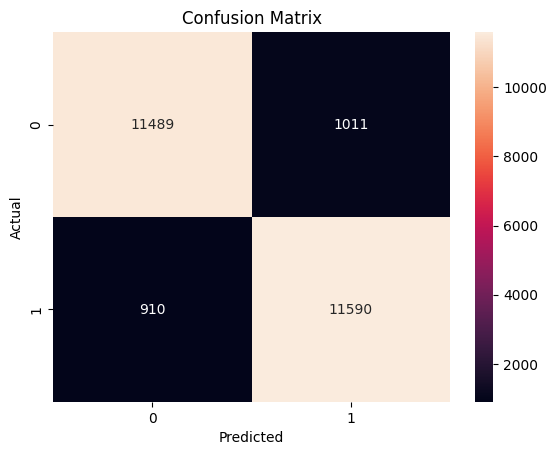

In [17]:
trainer.train()

predictions = trainer.predict(test_data)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

print(compute_metrics((predictions.predictions, y_true)))


cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Only Train The Classifier

In [18]:
model_freeze = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

for param in model_freeze.bert.parameters():
    param.requires_grad = False

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [39]:
trainer = Trainer(
    model=model_freeze,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.669279,0.663109,0.612237,0.701218,0.565743,0.922003
2,0.660562,0.653631,0.638574,0.710578,0.587446,0.899015


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5626, training_loss=0.669583675575731, metrics={'train_runtime': 217.9478, 'train_samples_per_second': 206.508, 'train_steps_per_second': 25.814, 'total_flos': 5919998745600000.0, 'train_loss': 0.669583675575731, 'epoch': 2.0})

In [40]:
predictions = trainer.predict(test_data)

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [41]:
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

Accuracy: 0.63096
Precision: 0.5860039928548912
Recall: 0.89232
F1 Score: 0.7074269042937782


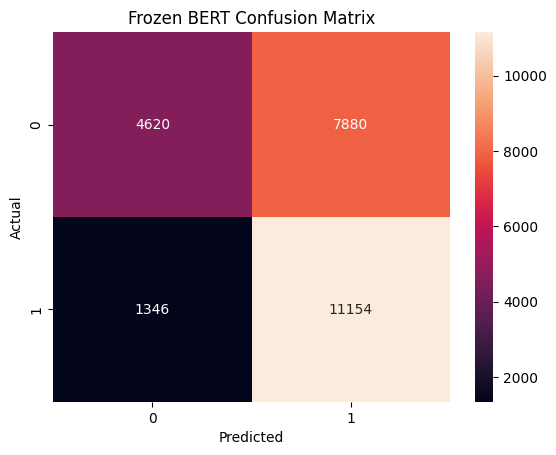

In [42]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Frozen BERT Confusion Matrix")
plt.show()

## Only Fine Tuning the last two layers only

In [19]:
model_partial = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

for name, param in model_partial.bert.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [37]:
partial_trainer = Trainer(
    model=model_partial,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.167167,0.373740,0.918152,0.918351,0.904459,0.932677
2,0.088374,0.434372,0.923825,0.923763,0.912660,0.935140


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5626, training_loss=0.12429336106442405, metrics={'train_runtime': 1176.8573, 'train_samples_per_second': 38.244, 'train_steps_per_second': 4.781, 'total_flos': 5919998745600000.0, 'train_loss': 0.12429336106442405, 'epoch': 2.0})

In [45]:
predictions = partial_trainer.predict(test_data)

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'accuracy': 0.51956, 'f1': 0.3864739234816366, 'precision': 0.5345485375158966, 'recall': 0.30264}


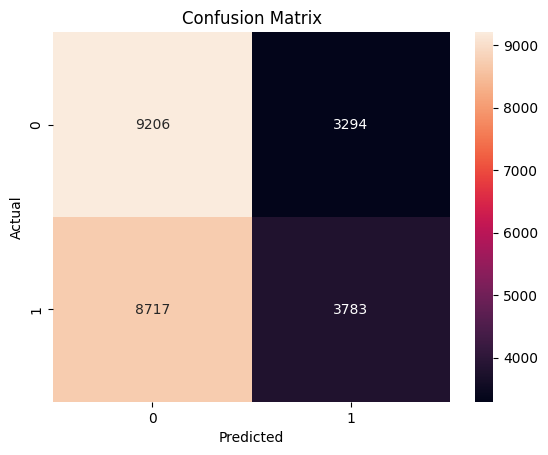

In [46]:
print(compute_metrics((predictions.predictions, y_true)))


cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [47]:
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

Accuracy: 0.51956
Precision: 0.5345485375158966
Recall: 0.30264
F1 Score: 0.3864739234816366


## Using a CatBoostModel to feed its embeddings and boost robustness (Representation Learning)

In [20]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 4.3 MB/s eta 0:00:00


In [32]:
from catboost import CatBoostClassifier
from tqdm import tqdm

def extract_embeddings(dataset):
    embeddings = []
    labels = []
    # Detect the device the model is currently on (XLA, CUDA, or CPU)
    device = next(model.parameters()).device
    model.eval()

    for batch in tqdm(dataset):
        # Move input tensors to the model's device
        input_ids = batch['input_ids'].unsqueeze(0).to(device)
        attention_mask = batch['attention_mask'].unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model.bert(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        # Move the result back to CPU to convert to numpy
        cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()

        embeddings.append(cls_embedding)
        labels.append(batch['label'].item())

    return np.array(embeddings), np.array(labels)

In [33]:
X_train, y_train = extract_embeddings(train_dataset)
X_val, y_val = extract_embeddings(val_dataset)
X_test, y_test = extract_embeddings(test_data)

100%|██████████| 25000/25000 [06:41<00:00, 62.20it/s]


In [34]:
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=100
) #Standard Parameters for research and experiment

cat_model.fit(X_train, y_train, eval_set=(X_val, y_val))

0:	learn: 0.5861537	test: 0.5991436	best: 0.5991436 (0)	total: 114ms	remaining: 56.9s
100:	learn: 0.0564817	test: 0.2376009	best: 0.2117970 (21)	total: 5.43s	remaining: 21.4s
200:	learn: 0.0467107	test: 0.2410064	best: 0.2117970 (21)	total: 10.5s	remaining: 15.7s
300:	learn: 0.0393297	test: 0.2452504	best: 0.2117970 (21)	total: 16.3s	remaining: 10.8s
400:	learn: 0.0333459	test: 0.2499631	best: 0.2117970 (21)	total: 21.7s	remaining: 5.36s
499:	learn: 0.0290593	test: 0.2541719	best: 0.2117970 (21)	total: 28s	remaining: 0us

bestTest = 0.2117969874
bestIteration = 21

Shrink model to first 22 iterations.


CatBoostClassifier(depth=6, iterations=500, learning_rate=0.05, verbose=100)

In [35]:
y_pred = cat_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.92404
F1: 0.9240126445520387
Precision: 0.9243455287807221
Recall: 0.92368


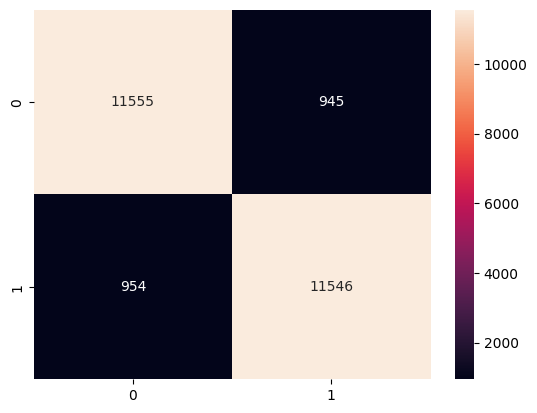

In [36]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

##Results

In [48]:
#Full Fine Tune: {'accuracy': 0.92316, 'f1': 0.9234691844946417, 'precision': 0.9197682723593366, 'recall': 0.9272}
#Frozen BERT: Accuracy: 0.63096, Precision: 0.5860039928548912, Recall: 0.89232, F1 Score: 0.7074269042937782
#Last 2 layers: Accuracy: 0.51956, Precision: 0.5345485375158966, Recall: 0.30264, F1 Score: 0.3864739234816366
#Representation Learning: Accuracy: 0.92404, F1: 0.9240126445520387, Precision: 0.9243455287807221, Recall: 0.92368
#Results
results = pd.DataFrame({
    "Model": ["Full Fine-tune", "Frozen BERT", "Last 2 Layers", "Representation Learning"],
    "Accuracy": [0.92, 0.63, 0.51, 0.93],
    "F1 Score": [0.93, 0.70, 0.38, 0.93]
})

results

,Model,Accuracy,F1 Score
0,Full Fine-tune,0.92,0.93
1,Frozen BERT,0.63,0.70
2,Last 2 Layers,0.51,0.38
3,Representation Learning,0.93,0.93


In [49]:
results.to_csv("results.csv", index=False)